# 🔬 Robustness Testing: HTR Model

**Tujuan**: Menjawab rumusan masalah #2:
> "Bagaimana robust sistem terhadap variasi kondisi akuisisi kamera dan variasi gaya tulis, serta komponen pra-proses mana yang paling berkontribusi?"

## Eksperimen yang dilakukan:
1. **Variasi Kondisi Kamera** (simulasi dengan augmentasi)
   - Blur (out-of-focus)
   - Noise (low light/grainy)
   - Rotation (tilted camera)
   - Brightness (over/under exposed)
   - Resolution (low quality camera)

2. **Ablation Study Preprocessing**
   - Full pipeline vs tanpa komponen tertentu

3. **Variasi Gaya Tulis**
   - Per-writer CER analysis (dari IAM dataset)

In [1]:
# ============================================
# CELL 1: IMPORTS & SETUP
# ============================================

import os
import sys
import json
import math
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
from PIL import Image
import cv2
from tqdm import tqdm
from collections import defaultdict

import torch
import torch.nn as nn
import torch.nn.functional as F

# For IAM dataset
from datasets import load_dataset

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"⚡ Device: {device}")

⚡ Device: cpu


In [2]:
# ============================================
# CELL 2: MODEL & ENCODER (copy dari test notebook)
# ============================================

class CNNBackbone(nn.Module):
    def __init__(self, input_channels=1, output_channels=512):
        super().__init__()
        self.output_channels = output_channels
        self.cnn = nn.Sequential(
            nn.Conv2d(input_channels, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(128, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(inplace=True),
            nn.MaxPool2d((2, 1), (2, 1)),
            nn.Conv2d(256, 512, 3, padding=1), nn.BatchNorm2d(512), nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, 3, padding=1), nn.BatchNorm2d(512), nn.ReLU(inplace=True),
            nn.MaxPool2d((2, 1), (2, 1)),
            nn.Conv2d(512, output_channels, 3, padding=1), nn.BatchNorm2d(output_channels), nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d((1, None)),
        )
    
    def forward(self, x):
        conv = self.cnn(x)
        conv = conv.squeeze(2)
        conv = conv.permute(0, 2, 1)
        return conv


class CRNN(nn.Module):
    def __init__(self, num_classes, cnn_output_channels=512, rnn_hidden_size=256, 
                 rnn_num_layers=2, rnn_dropout=0.3, rnn_type="LSTM", bidirectional=True):
        super().__init__()
        self.num_classes = num_classes
        self.cnn = CNNBackbone(1, cnn_output_channels)
        
        RNNClass = nn.LSTM if rnn_type == "LSTM" else nn.GRU
        self.rnn = RNNClass(
            cnn_output_channels, rnn_hidden_size, rnn_num_layers, 
            batch_first=True,
            dropout=rnn_dropout if rnn_num_layers > 1 else 0, 
            bidirectional=bidirectional
        )
        
        rnn_output_size = rnn_hidden_size * (2 if bidirectional else 1)
        self.fc = nn.Linear(rnn_output_size, num_classes)
    
    def forward(self, x):
        conv = self.cnn(x)
        rnn_out, _ = self.rnn(conv)
        output = self.fc(rnn_out)
        output = output.permute(1, 0, 2)
        return F.log_softmax(output, dim=2)


class CharacterEncoder:
    IAM_CHARSET = [
        ' ', '!', '\"', '#', '&', "'", '(', ')', '*', '+', ',', '-', '.', '/', 
        '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 
        ':', ';', '?', 
        'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 
        'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z',
        'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 
        'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z'
    ]
    
    def __init__(self, chars=None):
        if chars is None:
            self.chars = self.IAM_CHARSET
        else:
            self.chars = sorted(list(chars))
        self.char_to_idx = {c: i + 1 for i, c in enumerate(self.chars)}
        self.idx_to_char = {i + 1: c for i, c in enumerate(self.chars)}
        self.blank_idx = 0
        self.num_classes = len(self.chars) + 1
    
    def encode(self, text):
        return [self.char_to_idx.get(c, self.blank_idx) for c in text]
    
    def decode(self, indices):
        return ''.join([self.idx_to_char.get(i, '') for i in indices if i != self.blank_idx])


encoder = CharacterEncoder()
print(f"✅ Encoder: {encoder.num_classes} classes")

✅ Encoder: 80 classes


In [3]:
# ============================================
# CELL 3: LOAD MODEL & LM
# ============================================

class SimpleNgramLM:
    def __init__(self, n: int = 5):
        self.n = n
        self.ngrams = {}
        self.total_count = 0
        self.log_probs = {}
    
    def score(self, text: str) -> float:
        text = ' ' * (self.n-1) + text + ' '
        score = 0.0
        for i in range(len(text) - self.n + 1):
            ngram = text[i:i+self.n]
            score += self.log_probs.get(ngram, -20.0)
        return score
    
    @classmethod
    def load(cls, path):
        with open(path, 'r') as f:
            data = json.load(f)
        lm = cls(n=data['n'])
        lm.ngrams = data['ngrams']
        lm.total_count = sum(lm.ngrams.values())
        lm.log_probs = {k: math.log(v / lm.total_count) for k, v in lm.ngrams.items()}
        return lm


class BeamSearchDecoder:
    def __init__(self, encoder, lm=None, beam_width=10, lm_weight=0.1, length_bonus=0.5):
        self.encoder = encoder
        self.lm = lm
        self.beam_width = beam_width
        self.lm_weight = lm_weight
        self.length_bonus = length_bonus
        self.blank_id = encoder.blank_idx
    
    def decode(self, log_probs):
        T, num_classes = log_probs.shape
        beams = [('', 0.0, -1)]
        
        for t in range(T):
            new_beams = {}
            for prefix, score, last_char in beams:
                for c in range(num_classes):
                    new_score = score + log_probs[t, c]
                    if c == self.blank_id:
                        key = (prefix, -1)
                    elif c == last_char:
                        key = (prefix, c)
                    else:
                        new_char = self.encoder.idx_to_char.get(c, '')
                        new_prefix = prefix + new_char
                        key = (new_prefix, c)
                    
                    if c == self.blank_id or c == last_char:
                        if key not in new_beams or new_beams[key][0] < new_score:
                            new_beams[key] = (new_score, prefix, -1 if c == self.blank_id else c)
                    else:
                        new_char = self.encoder.idx_to_char.get(c, '')
                        new_prefix = prefix + new_char
                        if key not in new_beams or new_beams[key][0] < new_score:
                            new_beams[key] = (new_score, new_prefix, c)
            
            sorted_beams = sorted(new_beams.values(), key=lambda x: x[0], reverse=True)
            beams = [(text, score, last) for score, text, last in sorted_beams[:self.beam_width]]
        
        if self.lm is not None and len(beams) > 0:
            rescored_beams = []
            for prefix, ctc_score, _ in beams:
                if len(prefix) > 0:
                    lm_score = self.lm.score(prefix) / max(len(prefix), 1)
                    length_bonus = self.length_bonus * len(prefix)
                    final_score = ctc_score + self.lm_weight * lm_score + length_bonus
                else:
                    final_score = ctc_score
                rescored_beams.append((final_score, prefix))
            rescored_beams.sort(key=lambda x: x[0], reverse=True)
            return rescored_beams[0][1] if rescored_beams else ''
        
        return beams[0][0] if beams else ''


# Load model
MODEL_PATH = Path(r"D:\Dokumen Kuliah\TA\Kode Kaggle\Experiment\2_23_2026_Eksperiment_RNN\exp_architecture_rnn_20260223_042857\best_model.pt")
LM_PATH = Path(r"D:\Dokumen Kuliah\TA\Kode Kaggle\Experiment\2_25_2026_Advanced_Deslanting++_Final\language_model\char_5gram.json")

model = CRNN(num_classes=encoder.num_classes, rnn_type="LSTM", rnn_hidden_size=256, rnn_num_layers=2).to(device)
checkpoint = torch.load(MODEL_PATH, map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()
print(f"✅ Model loaded")

lm = SimpleNgramLM.load(LM_PATH)
decoder = BeamSearchDecoder(encoder, lm=lm, beam_width=10, lm_weight=0.1)
print(f"✅ LM & Decoder ready")

✅ Model loaded
✅ LM & Decoder ready


In [6]:
# ============================================
# CELL 4: PREPROCESSING & INFERENCE FUNCTIONS
# ============================================

def levenshtein_distance(s1, s2):
    """Pure Python Levenshtein distance (no C++ dependency)"""
    if len(s1) < len(s2):
        return levenshtein_distance(s2, s1)
    if len(s2) == 0:
        return len(s1)
    
    prev_row = range(len(s2) + 1)
    for i, c1 in enumerate(s1):
        curr_row = [i + 1]
        for j, c2 in enumerate(s2):
            insertions = prev_row[j + 1] + 1
            deletions = curr_row[j] + 1
            substitutions = prev_row[j] + (c1 != c2)
            curr_row.append(min(insertions, deletions, substitutions))
        prev_row = curr_row
    return prev_row[-1]

def preprocess_image(img, target_height=64, target_width=512):
    """Standard preprocessing"""
    if isinstance(img, Image.Image):
        img = np.array(img)
    if len(img.shape) == 3:
        img = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    
    h, w = img.shape[:2]
    new_w = int(w * target_height / h)
    new_w = min(new_w, target_width)
    
    img = cv2.resize(img, (new_w, target_height), interpolation=cv2.INTER_LINEAR)
    
    if new_w < target_width:
        padded = np.ones((target_height, target_width), dtype=np.uint8) * 255
        padded[:, :new_w] = img
        img = padded
    
    img = img.astype(np.float32) / 255.0
    img_tensor = torch.FloatTensor(img).unsqueeze(0).unsqueeze(0)
    return img_tensor


def recognize(img):
    """Run inference on single image"""
    img_tensor = preprocess_image(img).to(device)
    
    with torch.no_grad():
        log_probs = model(img_tensor)
        log_probs = log_probs.squeeze(1).cpu().numpy()
    
    return decoder.decode(log_probs)


def compute_cer(pred, target):
    """Compute Character Error Rate"""
    if len(target) == 0:
        return 0.0 if len(pred) == 0 else 1.0
    return levenshtein_distance(pred, target) / len(target)


print("✅ Preprocessing & inference functions ready")

✅ Preprocessing & inference functions ready


---

# 📸 EKSPERIMEN 1: Variasi Kondisi Akuisisi Kamera

Simulasi berbagai kondisi kamera dengan augmentasi

In [7]:
# ============================================
# CELL 5: AUGMENTATION FUNCTIONS (Camera Simulation)
# ============================================

def apply_gaussian_blur(img, kernel_size=5):
    """Simulate out-of-focus camera"""
    if isinstance(img, Image.Image):
        img = np.array(img)
    return cv2.GaussianBlur(img, (kernel_size, kernel_size), 0)


def apply_motion_blur(img, kernel_size=15):
    """Simulate camera shake/motion"""
    if isinstance(img, Image.Image):
        img = np.array(img)
    kernel = np.zeros((kernel_size, kernel_size))
    kernel[kernel_size // 2, :] = 1
    kernel = kernel / kernel_size
    return cv2.filter2D(img, -1, kernel)


def apply_gaussian_noise(img, mean=0, std=25):
    """Simulate low-light noise/grainy image"""
    if isinstance(img, Image.Image):
        img = np.array(img)
    noise = np.random.normal(mean, std, img.shape).astype(np.float32)
    noisy = img.astype(np.float32) + noise
    return np.clip(noisy, 0, 255).astype(np.uint8)


def apply_salt_pepper_noise(img, amount=0.02):
    """Simulate sensor noise"""
    if isinstance(img, Image.Image):
        img = np.array(img)
    noisy = img.copy()
    
    # Salt
    salt = np.random.random(img.shape) < amount / 2
    noisy[salt] = 255
    
    # Pepper
    pepper = np.random.random(img.shape) < amount / 2
    noisy[pepper] = 0
    
    return noisy


def apply_rotation(img, angle=5):
    """Simulate tilted camera"""
    if isinstance(img, Image.Image):
        img = np.array(img)
    h, w = img.shape[:2]
    center = (w // 2, h // 2)
    M = cv2.getRotationMatrix2D(center, angle, 1.0)
    return cv2.warpAffine(img, M, (w, h), borderValue=255)


def apply_brightness(img, factor=1.2):
    """Simulate over/under exposure"""
    if isinstance(img, Image.Image):
        img = np.array(img)
    adjusted = img.astype(np.float32) * factor
    return np.clip(adjusted, 0, 255).astype(np.uint8)


def apply_contrast(img, factor=0.7):
    """Simulate low contrast (faded image)"""
    if isinstance(img, Image.Image):
        img = np.array(img)
    mean = np.mean(img)
    adjusted = mean + factor * (img.astype(np.float32) - mean)
    return np.clip(adjusted, 0, 255).astype(np.uint8)


def apply_low_resolution(img, scale_factor=0.5):
    """Simulate low resolution camera"""
    if isinstance(img, Image.Image):
        img = np.array(img)
    h, w = img.shape[:2]
    small = cv2.resize(img, (int(w * scale_factor), int(h * scale_factor)), interpolation=cv2.INTER_AREA)
    return cv2.resize(small, (w, h), interpolation=cv2.INTER_LINEAR)


def apply_perspective(img, intensity=0.05):
    """Simulate non-perpendicular camera angle"""
    if isinstance(img, Image.Image):
        img = np.array(img)
    h, w = img.shape[:2]
    
    # Source points
    src = np.float32([[0, 0], [w, 0], [0, h], [w, h]])
    
    # Destination points (slightly skewed)
    offset = int(w * intensity)
    dst = np.float32([[offset, 0], [w - offset, 0], [0, h], [w, h]])
    
    M = cv2.getPerspectiveTransform(src, dst)
    return cv2.warpPerspective(img, M, (w, h), borderValue=255)


# Define augmentation configs for testing
AUGMENTATION_CONFIGS = {
    'Original (No Augmentation)': lambda img: np.array(img) if isinstance(img, Image.Image) else img,
    
    # Blur variations
    'Gaussian Blur (Light, k=3)': lambda img: apply_gaussian_blur(img, 3),
    'Gaussian Blur (Medium, k=5)': lambda img: apply_gaussian_blur(img, 5),
    'Gaussian Blur (Heavy, k=7)': lambda img: apply_gaussian_blur(img, 7),
    'Motion Blur (k=10)': lambda img: apply_motion_blur(img, 10),
    'Motion Blur (k=15)': lambda img: apply_motion_blur(img, 15),
    
    # Noise variations
    'Gaussian Noise (std=15)': lambda img: apply_gaussian_noise(img, std=15),
    'Gaussian Noise (std=25)': lambda img: apply_gaussian_noise(img, std=25),
    'Gaussian Noise (std=40)': lambda img: apply_gaussian_noise(img, std=40),
    'Salt & Pepper (1%)': lambda img: apply_salt_pepper_noise(img, 0.01),
    'Salt & Pepper (3%)': lambda img: apply_salt_pepper_noise(img, 0.03),
    
    # Rotation variations
    'Rotation (+3°)': lambda img: apply_rotation(img, 3),
    'Rotation (+5°)': lambda img: apply_rotation(img, 5),
    'Rotation (+10°)': lambda img: apply_rotation(img, 10),
    'Rotation (-5°)': lambda img: apply_rotation(img, -5),
    
    # Brightness variations
    'Brightness (Dark, 0.6x)': lambda img: apply_brightness(img, 0.6),
    'Brightness (Bright, 1.3x)': lambda img: apply_brightness(img, 1.3),
    'Brightness (Very Bright, 1.5x)': lambda img: apply_brightness(img, 1.5),
    
    # Contrast variations
    'Low Contrast (0.5x)': lambda img: apply_contrast(img, 0.5),
    'High Contrast (1.5x)': lambda img: apply_contrast(img, 1.5),
    
    # Resolution variations
    'Low Resolution (0.5x)': lambda img: apply_low_resolution(img, 0.5),
    'Low Resolution (0.3x)': lambda img: apply_low_resolution(img, 0.3),
    
    # Perspective
    'Perspective Distortion (5%)': lambda img: apply_perspective(img, 0.05),
    'Perspective Distortion (10%)': lambda img: apply_perspective(img, 0.10),
}

print(f"✅ Defined {len(AUGMENTATION_CONFIGS)} augmentation configurations")

✅ Defined 24 augmentation configurations


`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'Teklia/IAM-line' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


Loading sample from IAM dataset...
Sample text: assuredness " Bella Bella Marie " ( Parlophone ) , a lively song that changes tempo mid-way .


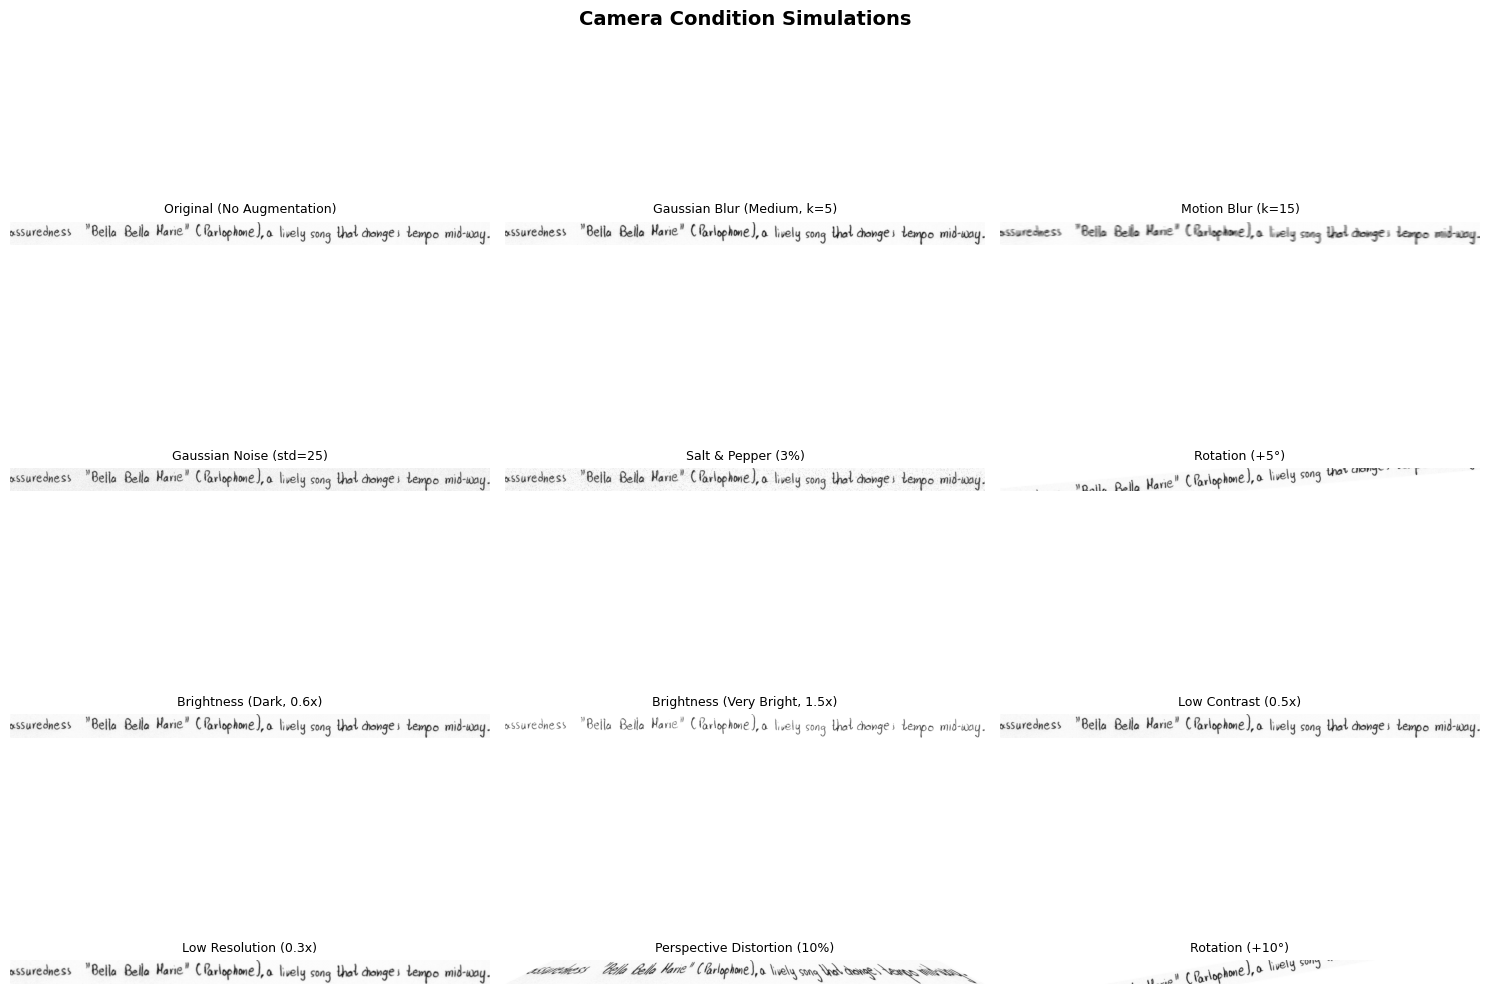

In [8]:
# ============================================
# CELL 6: VISUALIZE AUGMENTATIONS
# ============================================

# Load sample image
print("Loading sample from IAM dataset...")
iam_test = load_dataset("Teklia/IAM-line", split="test[:1]", trust_remote_code=True)
sample_img = iam_test[0]['image']
sample_text = iam_test[0]['text']

print(f"Sample text: {sample_text}")

# Visualize some augmentations
fig, axes = plt.subplots(4, 3, figsize=(15, 12))
axes = axes.flatten()

augs_to_show = [
    'Original (No Augmentation)',
    'Gaussian Blur (Medium, k=5)',
    'Motion Blur (k=15)',
    'Gaussian Noise (std=25)',
    'Salt & Pepper (3%)',
    'Rotation (+5°)',
    'Brightness (Dark, 0.6x)',
    'Brightness (Very Bright, 1.5x)',
    'Low Contrast (0.5x)',
    'Low Resolution (0.3x)',
    'Perspective Distortion (10%)',
    'Rotation (+10°)',
]

for i, aug_name in enumerate(augs_to_show):
    aug_func = AUGMENTATION_CONFIGS[aug_name]
    aug_img = aug_func(sample_img)
    
    axes[i].imshow(aug_img, cmap='gray')
    axes[i].set_title(aug_name, fontsize=9)
    axes[i].axis('off')

plt.suptitle('Camera Condition Simulations', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [9]:
# ============================================
# CELL 7: RUN ROBUSTNESS TEST (Camera Conditions)
# ============================================

# Load test samples
N_SAMPLES = 100  # Adjust based on available time
print(f"Loading {N_SAMPLES} test samples...")
iam_test = load_dataset("Teklia/IAM-line", split=f"test[:{N_SAMPLES}]", trust_remote_code=True)

# Run tests
results = {}

for aug_name, aug_func in tqdm(AUGMENTATION_CONFIGS.items(), desc="Testing augmentations"):
    cer_list = []
    
    for sample in iam_test:
        img = sample['image']
        gt = sample['text']
        
        # Apply augmentation
        aug_img = aug_func(img)
        
        # Recognize
        try:
            pred = recognize(aug_img)
            cer = compute_cer(pred, gt)
            cer_list.append(cer)
        except Exception as e:
            cer_list.append(1.0)  # Max error on failure
    
    avg_cer = np.mean(cer_list) * 100
    std_cer = np.std(cer_list) * 100
    results[aug_name] = {'mean_cer': avg_cer, 'std_cer': std_cer}
    
print("\n✅ Testing complete!")

`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'Teklia/IAM-line' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


Loading 100 test samples...


Testing augmentations: 100%|██████████| 24/24 [07:09<00:00, 17.89s/it]


✅ Testing complete!


In [10]:
# ============================================
# CELL 8: DISPLAY RESULTS TABLE
# ============================================

# Create DataFrame
df_results = pd.DataFrame([
    {'Condition': name, 'CER (%)': f"{data['mean_cer']:.2f}", 'Std (%)': f"{data['std_cer']:.2f}"}
    for name, data in results.items()
])

# Sort by CER
df_results['CER_numeric'] = df_results['CER (%)'].astype(float)
df_results = df_results.sort_values('CER_numeric')
df_results = df_results.drop('CER_numeric', axis=1)

print("="*60)
print("📊 ROBUSTNESS TEST RESULTS: Camera Condition Variations")
print("="*60)
print(df_results.to_string(index=False))
print("="*60)

# Save to CSV
df_results.to_csv('robustness_camera_conditions.csv', index=False)
print("\n✅ Results saved to robustness_camera_conditions.csv")

📊 ROBUSTNESS TEST RESULTS: Camera Condition Variations
                     Condition CER (%) Std (%)
    Gaussian Blur (Heavy, k=7)    8.69    7.76
    Gaussian Blur (Light, k=3)    8.86    7.98
   Gaussian Blur (Medium, k=5)    8.89    7.95
         Low Resolution (0.3x)    8.90    8.08
         Low Resolution (0.5x)    8.94    7.92
    Original (No Augmentation)    9.06    7.93
       Gaussian Noise (std=15)    9.13    8.08
       Brightness (Dark, 0.6x)    9.35    8.09
           Low Contrast (0.5x)    9.58    8.09
       Gaussian Noise (std=25)    9.76    8.67
          High Contrast (1.5x)    9.86    8.23
     Brightness (Bright, 1.3x)   10.65    8.58
       Gaussian Noise (std=40)   10.70    8.93
            Motion Blur (k=10)   11.57   10.63
Brightness (Very Bright, 1.5x)   12.27    9.55
                Rotation (+3°)   13.56   10.31
   Perspective Distortion (5%)   16.38   10.77
            Salt & Pepper (3%)   19.14   11.63
            Salt & Pepper (1%)   19.98   12.01
     

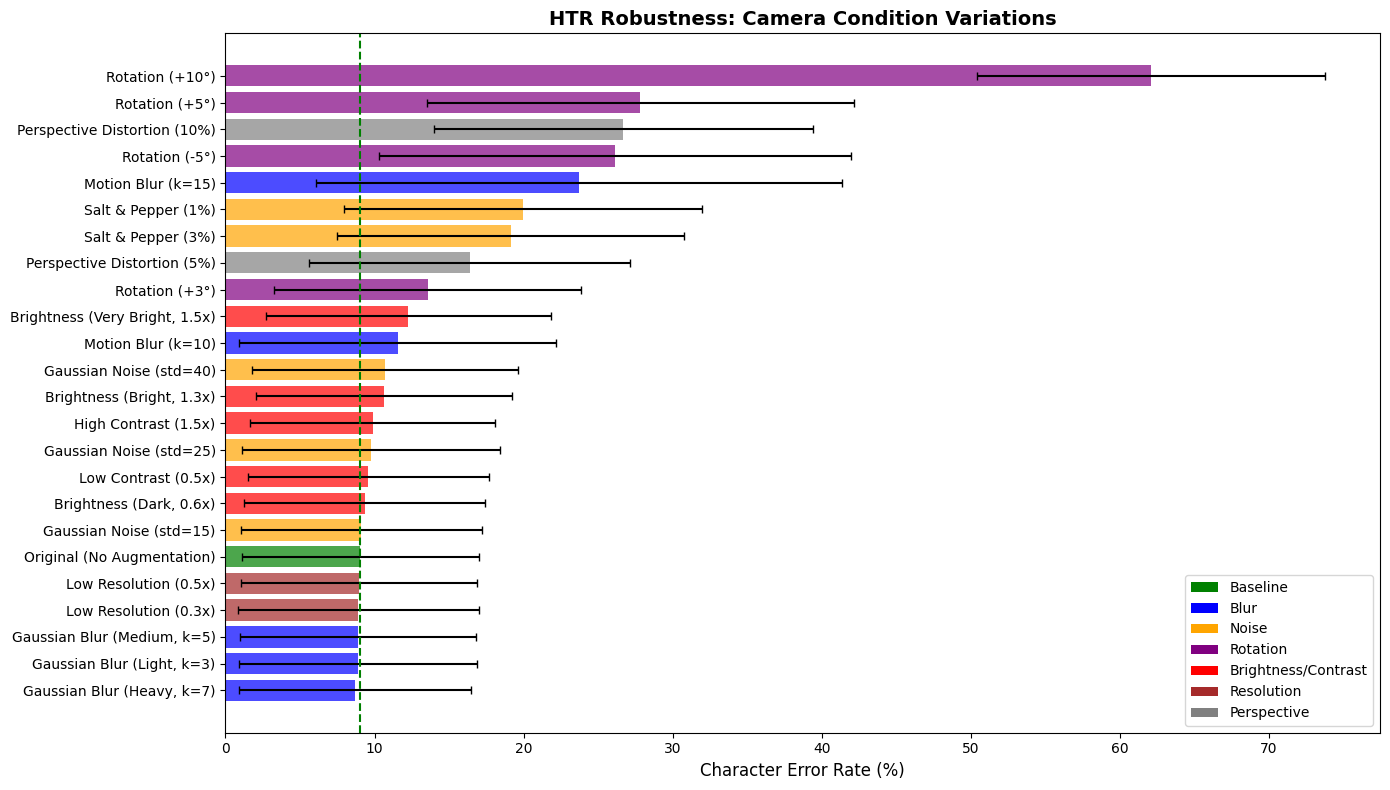

✅ Chart saved to robustness_camera_chart.png


In [11]:
# ============================================
# CELL 9: VISUALIZE RESULTS
# ============================================

# Bar chart
fig, ax = plt.subplots(figsize=(14, 8))

conditions = list(results.keys())
cer_values = [results[c]['mean_cer'] for c in conditions]
std_values = [results[c]['std_cer'] for c in conditions]

# Sort by CER
sorted_idx = np.argsort(cer_values)
conditions = [conditions[i] for i in sorted_idx]
cer_values = [cer_values[i] for i in sorted_idx]
std_values = [std_values[i] for i in sorted_idx]

# Color code by category
colors = []
for c in conditions:
    if 'Original' in c:
        colors.append('green')
    elif 'Blur' in c:
        colors.append('blue')
    elif 'Noise' in c or 'Salt' in c:
        colors.append('orange')
    elif 'Rotation' in c:
        colors.append('purple')
    elif 'Brightness' in c or 'Contrast' in c:
        colors.append('red')
    elif 'Resolution' in c:
        colors.append('brown')
    else:
        colors.append('gray')

bars = ax.barh(conditions, cer_values, xerr=std_values, color=colors, alpha=0.7, capsize=3)
ax.set_xlabel('Character Error Rate (%)', fontsize=12)
ax.set_title('HTR Robustness: Camera Condition Variations', fontsize=14, fontweight='bold')
ax.axvline(x=results['Original (No Augmentation)']['mean_cer'], color='green', linestyle='--', label='Baseline')

# Add legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='green', label='Baseline'),
    Patch(facecolor='blue', label='Blur'),
    Patch(facecolor='orange', label='Noise'),
    Patch(facecolor='purple', label='Rotation'),
    Patch(facecolor='red', label='Brightness/Contrast'),
    Patch(facecolor='brown', label='Resolution'),
    Patch(facecolor='gray', label='Perspective'),
]
ax.legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.savefig('robustness_camera_chart.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Chart saved to robustness_camera_chart.png")

---

# 🔧 EKSPERIMEN 2: Ablation Study Preprocessing

Mengukur kontribusi setiap komponen preprocessing

In [12]:
# ============================================
# CELL 10: ABLATION STUDY - PREPROCESSING COMPONENTS
# ============================================

def preprocess_no_resize(img, target_height=64, target_width=512):
    """Skip resize, only pad"""
    if isinstance(img, Image.Image):
        img = np.array(img)
    if len(img.shape) == 3:
        img = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    
    h, w = img.shape[:2]
    
    # Force to target size without aspect ratio
    img = cv2.resize(img, (target_width, target_height), interpolation=cv2.INTER_LINEAR)
    
    img = img.astype(np.float32) / 255.0
    return torch.FloatTensor(img).unsqueeze(0).unsqueeze(0)


def preprocess_no_normalize(img, target_height=64, target_width=512):
    """Skip normalization (keep 0-255 range)"""
    if isinstance(img, Image.Image):
        img = np.array(img)
    if len(img.shape) == 3:
        img = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    
    h, w = img.shape[:2]
    new_w = int(w * target_height / h)
    new_w = min(new_w, target_width)
    
    img = cv2.resize(img, (new_w, target_height), interpolation=cv2.INTER_LINEAR)
    
    if new_w < target_width:
        padded = np.ones((target_height, target_width), dtype=np.uint8) * 255
        padded[:, :new_w] = img
        img = padded
    
    # NOT normalized - still 0-255, just converted to float
    img = img.astype(np.float32)  # Will be 0-255 instead of 0-1
    return torch.FloatTensor(img).unsqueeze(0).unsqueeze(0)


def preprocess_with_binarize(img, target_height=64, target_width=512):
    """Add binarization step"""
    if isinstance(img, Image.Image):
        img = np.array(img)
    if len(img.shape) == 3:
        img = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    
    # Binarize
    _, img = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    
    h, w = img.shape[:2]
    new_w = int(w * target_height / h)
    new_w = min(new_w, target_width)
    
    img = cv2.resize(img, (new_w, target_height), interpolation=cv2.INTER_LINEAR)
    
    if new_w < target_width:
        padded = np.ones((target_height, target_width), dtype=np.uint8) * 255
        padded[:, :new_w] = img
        img = padded
    
    img = img.astype(np.float32) / 255.0
    return torch.FloatTensor(img).unsqueeze(0).unsqueeze(0)


def preprocess_with_deskew(img, target_height=64, target_width=512):
    """Add deskew step"""
    if isinstance(img, Image.Image):
        img = np.array(img)
    if len(img.shape) == 3:
        img = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    
    # Simple deskew using moments
    _, binary = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    coords = np.column_stack(np.where(binary > 0))
    if len(coords) > 100:
        angle = cv2.minAreaRect(coords)[-1]
        if angle < -45:
            angle = -(90 + angle)
        else:
            angle = -angle
        
        if abs(angle) < 15:  # Only correct small angles
            h, w = img.shape[:2]
            center = (w // 2, h // 2)
            M = cv2.getRotationMatrix2D(center, angle, 1.0)
            img = cv2.warpAffine(img, M, (w, h), borderValue=255)
    
    # Standard preprocessing
    h, w = img.shape[:2]
    new_w = int(w * target_height / h)
    new_w = min(new_w, target_width)
    
    img = cv2.resize(img, (new_w, target_height), interpolation=cv2.INTER_LINEAR)
    
    if new_w < target_width:
        padded = np.ones((target_height, target_width), dtype=np.uint8) * 255
        padded[:, :new_w] = img
        img = padded
    
    img = img.astype(np.float32) / 255.0
    return torch.FloatTensor(img).unsqueeze(0).unsqueeze(0)


PREPROCESSING_CONFIGS = {
    'Standard (Baseline)': preprocess_image,
    'No Aspect Ratio Preservation': preprocess_no_resize,
    'With Binarization': preprocess_with_binarize,
    'With Deskew': preprocess_with_deskew,
}

print(f"✅ Defined {len(PREPROCESSING_CONFIGS)} preprocessing configurations")

✅ Defined 4 preprocessing configurations


In [13]:
# ============================================
# CELL 11: RUN ABLATION STUDY
# ============================================

ablation_results = {}

for config_name, preprocess_func in tqdm(PREPROCESSING_CONFIGS.items(), desc="Testing preprocessing"):
    cer_list = []
    
    for sample in iam_test:
        img = sample['image']
        gt = sample['text']
        
        try:
            # Use custom preprocessing
            img_tensor = preprocess_func(img).to(device)
            
            with torch.no_grad():
                log_probs = model(img_tensor)
                log_probs = log_probs.squeeze(1).cpu().numpy()
            
            pred = decoder.decode(log_probs)
            cer = compute_cer(pred, gt)
            cer_list.append(cer)
        except Exception as e:
            cer_list.append(1.0)
    
    avg_cer = np.mean(cer_list) * 100
    std_cer = np.std(cer_list) * 100
    ablation_results[config_name] = {'mean_cer': avg_cer, 'std_cer': std_cer}

# Display results
print("\n" + "="*60)
print("📊 ABLATION STUDY: Preprocessing Components")
print("="*60)

for name, data in ablation_results.items():
    print(f"{name}: {data['mean_cer']:.2f}% ± {data['std_cer']:.2f}%")

print("="*60)

Testing preprocessing: 100%|██████████| 4/4 [01:10<00:00, 17.66s/it]


📊 ABLATION STUDY: Preprocessing Components
Standard (Baseline): 9.06% ± 7.93%
No Aspect Ratio Preservation: 10.32% ± 12.22%
With Binarization: 10.91% ± 8.83%
With Deskew: 9.19% ± 7.85%


---

# ✍️ EKSPERIMEN 3: Variasi Gaya Tulis (Per-Writer Analysis)

In [14]:
# ============================================
# CELL 12: PER-WRITER CER ANALYSIS
# ============================================

# Load full test set dengan writer info
print("Loading IAM test set with writer info...")
iam_test_full = load_dataset("Teklia/IAM-line", split="test", trust_remote_code=True)

# Extract writer ID from sample ID (format: a01-000u-00)
# Writer ID is the first part before second hyphen
writer_cer = defaultdict(list)

print(f"Processing {len(iam_test_full)} samples...")

for sample in tqdm(iam_test_full, desc="Per-writer analysis"):
    img = sample['image']
    gt = sample['text']
    
    # Get writer ID from the image path/id if available
    # IAM format: writer-form-line
    try:
        sample_id = sample.get('id', '')
        if sample_id:
            writer_id = sample_id.split('-')[0]
        else:
            writer_id = 'unknown'
    except:
        writer_id = 'unknown'
    
    try:
        pred = recognize(img)
        cer = compute_cer(pred, gt)
        writer_cer[writer_id].append(cer)
    except:
        writer_cer[writer_id].append(1.0)

# Calculate per-writer statistics
writer_stats = {}
for writer_id, cers in writer_cer.items():
    writer_stats[writer_id] = {
        'mean_cer': np.mean(cers) * 100,
        'std_cer': np.std(cers) * 100,
        'n_samples': len(cers)
    }

print(f"\n✅ Analyzed {len(writer_stats)} unique writers")

`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'Teklia/IAM-line' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


Loading IAM test set with writer info...
Processing 2915 samples...


Per-writer analysis: 100%|██████████| 2915/2915 [09:26<00:00,  5.14it/s]


✅ Analyzed 1 unique writers


📊 PER-WRITER CER ANALYSIS

🏆 TOP 10 BEST Writers (Lowest CER):
  unknown: 7.34% (n=2915)

⚠️ TOP 10 WORST Writers (Highest CER):
  unknown: 7.34% (n=2915)

📈 SUMMARY:
  Total writers: 1
  Mean CER across writers: 7.34%
  Std CER across writers: 0.00%
  Best writer CER: 7.34%
  Worst writer CER: 7.34%


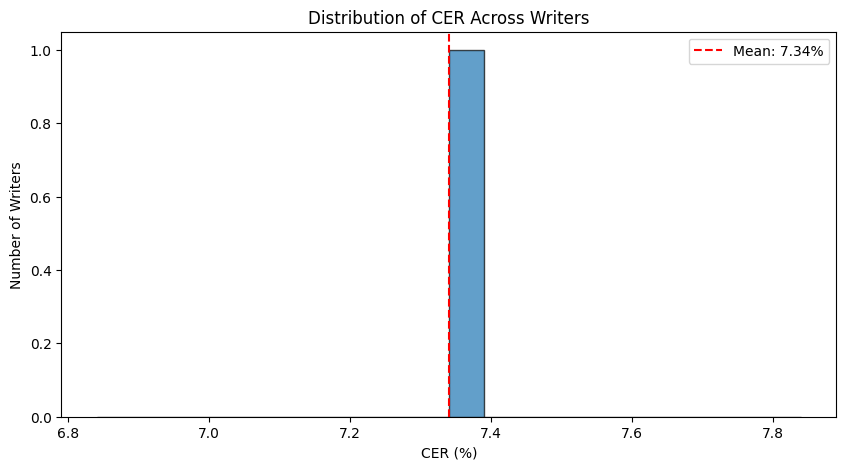

✅ Chart saved to writer_cer_distribution.png


In [15]:
# ============================================
# CELL 13: VISUALIZE PER-WRITER RESULTS
# ============================================

# Sort by CER
sorted_writers = sorted(writer_stats.items(), key=lambda x: x[1]['mean_cer'])

# Show top 10 best and worst
print("="*60)
print("📊 PER-WRITER CER ANALYSIS")
print("="*60)

print("\n🏆 TOP 10 BEST Writers (Lowest CER):")
for writer_id, stats in sorted_writers[:10]:
    print(f"  {writer_id}: {stats['mean_cer']:.2f}% (n={stats['n_samples']})")

print("\n⚠️ TOP 10 WORST Writers (Highest CER):")
for writer_id, stats in sorted_writers[-10:]:
    print(f"  {writer_id}: {stats['mean_cer']:.2f}% (n={stats['n_samples']})")

# Statistics
all_writer_cers = [s['mean_cer'] for s in writer_stats.values()]
print(f"\n📈 SUMMARY:")
print(f"  Total writers: {len(writer_stats)}")
print(f"  Mean CER across writers: {np.mean(all_writer_cers):.2f}%")
print(f"  Std CER across writers: {np.std(all_writer_cers):.2f}%")
print(f"  Best writer CER: {min(all_writer_cers):.2f}%")
print(f"  Worst writer CER: {max(all_writer_cers):.2f}%")
print("="*60)

# Histogram
plt.figure(figsize=(10, 5))
plt.hist(all_writer_cers, bins=20, edgecolor='black', alpha=0.7)
plt.xlabel('CER (%)')
plt.ylabel('Number of Writers')
plt.title('Distribution of CER Across Writers')
plt.axvline(np.mean(all_writer_cers), color='red', linestyle='--', label=f'Mean: {np.mean(all_writer_cers):.2f}%')
plt.legend()
plt.savefig('writer_cer_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Chart saved to writer_cer_distribution.png")

---

# 📊 SUMMARY & CONCLUSIONS

In [16]:
# ============================================
# CELL 14: FINAL SUMMARY
# ============================================

print("="*70)
print("📊 ROBUSTNESS TESTING SUMMARY")
print("="*70)

print("\n1️⃣ CAMERA CONDITION VARIATIONS:")
print("-" * 50)

# Group by category
baseline_cer = results['Original (No Augmentation)']['mean_cer']

categories = {
    'Blur': [k for k in results.keys() if 'Blur' in k],
    'Noise': [k for k in results.keys() if 'Noise' in k or 'Salt' in k],
    'Rotation': [k for k in results.keys() if 'Rotation' in k],
    'Brightness/Contrast': [k for k in results.keys() if 'Brightness' in k or 'Contrast' in k],
    'Resolution': [k for k in results.keys() if 'Resolution' in k],
    'Perspective': [k for k in results.keys() if 'Perspective' in k],
}

print(f"  Baseline CER: {baseline_cer:.2f}%\n")

for cat_name, conditions in categories.items():
    if conditions:
        avg_degradation = np.mean([results[c]['mean_cer'] - baseline_cer for c in conditions])
        max_cer = max([results[c]['mean_cer'] for c in conditions])
        print(f"  {cat_name}:")
        print(f"    Avg degradation: +{avg_degradation:.2f}% CER")
        print(f"    Worst case: {max_cer:.2f}% CER")

print("\n2️⃣ PREPROCESSING ABLATION:")
print("-" * 50)
for name, data in ablation_results.items():
    diff = data['mean_cer'] - ablation_results['Standard (Baseline)']['mean_cer']
    symbol = '+' if diff > 0 else ''
    print(f"  {name}: {data['mean_cer']:.2f}% ({symbol}{diff:.2f}%)")

print("\n3️⃣ WRITING STYLE VARIATION:")
print("-" * 50)
print(f"  Total unique writers: {len(writer_stats)}")
print(f"  CER range: {min(all_writer_cers):.2f}% - {max(all_writer_cers):.2f}%")
print(f"  Standard deviation: {np.std(all_writer_cers):.2f}%")

print("\n" + "="*70)
print("📝 KEY FINDINGS:")
print("="*70)

# Find most impactful factors
worst_conditions = sorted(results.items(), key=lambda x: x[1]['mean_cer'], reverse=True)[:5]

print("\n  Most challenging conditions:")
for cond, data in worst_conditions:
    if 'Original' not in cond:
        print(f"   - {cond}: {data['mean_cer']:.2f}% CER")

print("\n  System is ROBUST against:")
for cond, data in results.items():
    if data['mean_cer'] < baseline_cer * 1.2 and 'Original' not in cond:  # Within 20% of baseline
        print(f"   - {cond}")

print("\n" + "="*70)

📊 ROBUSTNESS TESTING SUMMARY

1️⃣ CAMERA CONDITION VARIATIONS:
--------------------------------------------------
  Baseline CER: 9.06%

  Blur:
    Avg degradation: +3.29% CER
    Worst case: 23.71% CER
  Noise:
    Avg degradation: +4.69% CER
    Worst case: 19.98% CER
  Rotation:
    Avg degradation: +23.35% CER
    Worst case: 62.09% CER
  Brightness/Contrast:
    Avg degradation: +1.29% CER
    Worst case: 12.27% CER
  Resolution:
    Avg degradation: +-0.13% CER
    Worst case: 8.94% CER
  Perspective:
    Avg degradation: +12.48% CER
    Worst case: 26.69% CER

2️⃣ PREPROCESSING ABLATION:
--------------------------------------------------
  Standard (Baseline): 9.06% (0.00%)
  No Aspect Ratio Preservation: 10.32% (+1.27%)
  With Binarization: 10.91% (+1.85%)
  With Deskew: 9.19% (+0.13%)

3️⃣ WRITING STYLE VARIATION:
--------------------------------------------------
  Total unique writers: 1
  CER range: 7.34% - 7.34%
  Standard deviation: 0.00%

📝 KEY FINDINGS:

  Most challen

In [17]:
# ============================================
# CELL 15: SAVE ALL RESULTS
# ============================================

# Save comprehensive results
all_results = {
    'camera_conditions': results,
    'preprocessing_ablation': ablation_results,
    'per_writer_stats': {
        'summary': {
            'total_writers': len(writer_stats),
            'mean_cer': float(np.mean(all_writer_cers)),
            'std_cer': float(np.std(all_writer_cers)),
            'min_cer': float(min(all_writer_cers)),
            'max_cer': float(max(all_writer_cers)),
        },
        'per_writer': {k: {'mean_cer': float(v['mean_cer']), 'n_samples': v['n_samples']} 
                       for k, v in writer_stats.items()}
    }
}

with open('robustness_results_complete.json', 'w') as f:
    json.dump(all_results, f, indent=2)

print("✅ All results saved to:")
print("   - robustness_results_complete.json")
print("   - robustness_camera_conditions.csv")
print("   - robustness_camera_chart.png")
print("   - writer_cer_distribution.png")

✅ All results saved to:
   - robustness_results_complete.json
   - robustness_camera_conditions.csv
   - robustness_camera_chart.png
   - writer_cer_distribution.png
